# Oncology Clinical Trial Data Pipeline: Data Ingestion & Schema Design 

**Author:** Anshu Mathuria 
**Objective:** Transform a raw, flat-file extract of oncology trial data (optimized for data entry) into a clean, normalized, and reproducible analytical schema. 

This notebook covers **Part 1** of the pipeline:
1. **Data Quality Audit (Part 1A):** Profiling the data for completeness, cardinality, dirty values, and structural anomalies *before* applying any transformations.
2. **Schema Engineering (Part 1B):** Designing a 1NF Star Schema to handle multi-valued fields, standardize controlled vocabularies, and engineer derived features for downstream cohort analysis.

## Part 1A: Parse and Profile the Raw Data
Before transforming the data, we must establish a baseline understanding of its quality and structural integrity. 

**Audit Strategy:**
* **Completeness & Cardinality:** Identifying structural missingness using visual matrices.
* **Structural Anomalies:** Checking for missing Primary Keys (`nct_id`), duplicate entries, and chronological "time-travel" errors (e.g., completion dates occurring before start dates).
* **Dirty Values:** Dynamically checking text columns for capitalization inconsistencies and utilizing **Fuzzy String Matching (`difflib`)** to detect typos and synonyms in categorical data.

In [4]:
#Setup & Data Loading
# !pip install pandas numpy plotly missingno matplotlib seaborn
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
import matplotlib.pyplot as plt
import ast
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 1. Load the raw data
raw_df = pd.read_excel('SampleDateExtract.xlsx')

print(f"Raw Data Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
raw_df.head(3)

Raw Data Shape: 1000 rows, 18 columns


,ID-datalake,nct_id,brief_title,official_title,phase,recruitment_status,start_date,completion_date,primary_completion_date,enrollment,enrollment_type,indications,interventions_drugs,drugs_datalake,main_technologies,specific_technologies,target_names,target_abbreviations
0,61690,NCT06669572,Lenvatinib and Pembrolizumab to Treat Patients...,"A Phase II, Multi-center, Single Arm Trial of ...",PHASE2,NOT_YET_RECRUITING,2026-01-13,2029-03-26,2029-03-26,35.0,ESTIMATED,"['Anorectal Cancer', 'Epithelial Neoplasm']","['Pembrolizumab', 'Lenvatinib']","['B936', 'B261']","[['Antibody'], ['Small Molecule']]","[['Monoclonal Antibody'], ['Small Molecule']]","[['Programmed cell death protein 1'], ['Fibrob...","[['PD-1'], ['FGFR1', 'FGFR2', 'FGFR3', 'FGFR4'..."
1,63117,NCT06883552,"An Open-label, Single-arm Clinical Study of St...","An Open-label, Single-arm Clinical Study of St...",PHASE2,NOT_YET_RECRUITING,2025-10-01,2026-10-01,2026-10-01,21.0,ESTIMATED,['Thoracic Neoplasm'],['Tislelizumab'],['B1344'],[['Antibody']],[['Monoclonal Antibody']],[['Programmed cell death protein 1']],[['PD-1']]
2,56177,NCT06366490,Safety and Immunogenicity of Innocell Autologo...,Phase 1 Study to Assess the Safety and Immunog...,PHASE1,NOT_YET_RECRUITING,2025-06-30,2026-06-30,2025-12-30,8.0,ESTIMATED,['Ovarian Cancer'],['Innocell'],['B11796'],[['Cancer Vaccine']],[['Whole Tumor Cell Vaccine']],[[]],[[]]


In [5]:
#Automated Data Quality Report (Completeness & Cardinality)
def generate_dq_report(df):
    """Generates a structured report on field completeness and cardinality."""
    dq_report = pd.DataFrame({
        'Data Type': df.dtypes,
        'Non-Null Count': df.notnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df)) * 100,
        'Unique Values (Cardinality)': df.nunique()
    }).sort_values(by='Missing (%)', ascending=False)
    
    return dq_report

dq_report = generate_dq_report(raw_df)
display(dq_report)

,Data Type,Non-Null Count,Missing (%),Unique Values (Cardinality)
completion_date,datetime64[us],948,5.2,600
primary_completion_date,datetime64[us],949,5.1,610
enrollment_type,str,956,4.4,2
phase,str,960,4.0,7
enrollment,float64,974,2.6,253
official_title,str,994,0.6,994
start_date,datetime64[us],995,0.5,693
ID-datalake,int64,1000,0.0,1000
nct_id,str,1000,0.0,1000
recruitment_status,str,1000,0.0,9


<Figure size 1200x600 with 0 Axes>

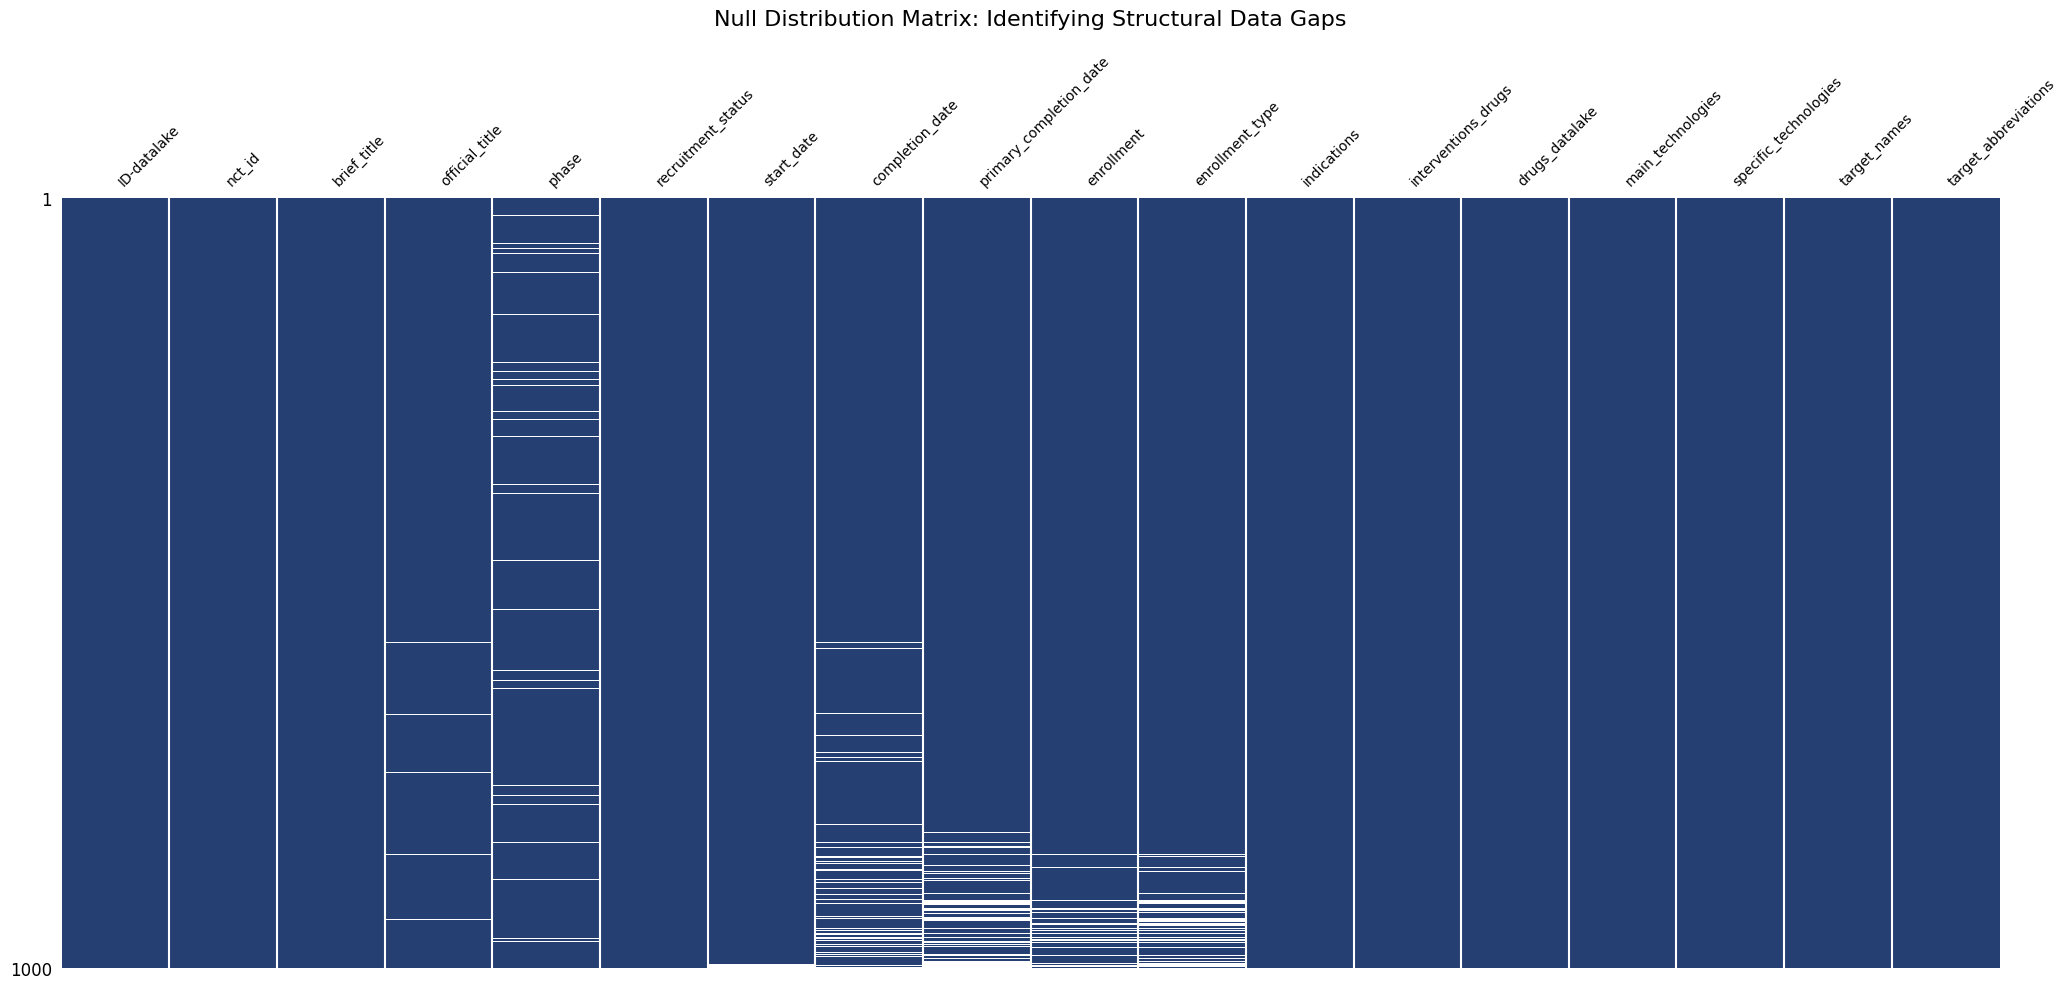

In [6]:
#Plot 1 - The Missing Data Matrix
# Visualizing structural missingness across the dataset
plt.figure(figsize=(12, 6))
msno.matrix(raw_df, sparkline=False, fontsize=10, color=(0.15, 0.25, 0.45))
plt.title("Null Distribution Matrix: Identifying Structural Data Gaps", fontsize=16, pad=20)
plt.show()

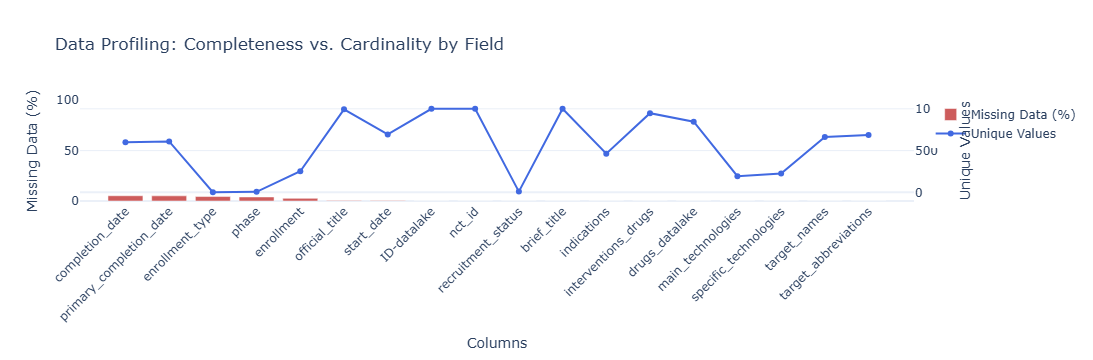

In [7]:
#Plot 2 - Interactive Cardinality & Completeness Bar Chart
# Plotly interactive dual-axis chart
fig = go.Figure()

# Bar chart for % Missing
fig.add_trace(go.Bar(
    x=dq_report.index, 
    y=dq_report['Missing (%)'],
    name='Missing Data (%)',
    marker_color='indianred'
))

# Line chart for Cardinality
fig.add_trace(go.Scatter(
    x=dq_report.index, 
    y=dq_report['Unique Values (Cardinality)'],
    name='Unique Values',
    yaxis='y2',
    mode='lines+markers',
    marker_color='royalblue'
))

fig.update_layout(
    title='Data Profiling: Completeness vs. Cardinality by Field',
    xaxis=dict(title='Columns', tickangle=-45),
    yaxis=dict(title='Missing Data (%)', range=[0, 100]),
    yaxis2=dict(title='Unique Values', overlaying='y', side='right'),
    hovermode='x unified',
    template='plotly_white'
)
fig.show()

In [15]:
import pandas as pd

print("==================================================")
print(" AUDIT REPORT: Structural Anomalies & Dirty Values")
print("==================================================\n")

# --- DYNAMIC COLUMN DETECTION ---
# Automatically find all text columns (excluding ID or URL columns to save processing)
text_cols = [col for col in raw_df.select_dtypes(include=['object', 'string']).columns 
             if 'id' not in col.lower() and 'url' not in col.lower()]

# Automatically find date columns (looking for 'date' or 'year' in the column name)
date_cols = [col for col in raw_df.columns if 'date' in col.lower() or 'year' in col.lower()]


# --- 1. STRUCTURAL ANOMALIES ---
print("1. STRUCTURAL ANOMALIES:")

# A. Duplicate Trial IDs
if 'nct_id' in raw_df.columns:
    duplicate_trials = raw_df['nct_id'].duplicated().sum()
    print(f"   - Duplicate Trial IDs found: {duplicate_trials}")

# B. Missing Primary Keys
    missing_ids = raw_df['nct_id'].isnull().sum()
    print(f"   - Rows with missing Primary Keys (Indicates merged cells/misalignment): {missing_ids}")
else:
    print("   - 'nct_id' column not found for structural checks.")


# --- 2. DIRTY VALUES (Dynamic Check) ---
print(f"\n2. DIRTY VALUES (Checking {len(text_cols)} text columns for inconsistent capitalization):")

for col in text_cols:
    raw_unique_count = raw_df[col].nunique()
    # Simulate cleaning just to count the difference
    clean_unique_count = raw_df[col].astype(str).str.lower().str.strip().nunique()
    
    inflation = raw_unique_count - clean_unique_count
    if inflation > 0:
        print(f"   - [{col.upper()}]: Found {inflation} duplicate categories due to capitalization/spacing.")
        print(f"        (Raw unique: {raw_unique_count} | Cleaned unique: {clean_unique_count})")
    else:
        # Optional: You can comment out the line below if you only want to print columns that HAVE errors
        print(f"   - [{col.upper()}]: Clean (No capitalization issues detected).")


# --- 3. DATE FORMAT VARIATIONS (Dynamic Check) ---
print(f"\n3. DATE FORMAT VARIATIONS (Checking {len(date_cols)} date columns):")

if not date_cols:
    print("   - No date columns detected based on column names.")
else:
    for col in date_cols:
        # Get the lengths of the date strings to see if formats vary
        date_lengths = raw_df[col].dropna().astype(str).apply(len).value_counts()
        if len(date_lengths) > 1:
            print(f"   - [{col.upper()}]: MULTIPLE date formats detected!")
            print(f"        String length variations: {date_lengths.to_dict()}")
        else:
            print(f"   - [{col.upper()}]: Consistent date string lengths.")

print("\n--- End of Data Quality Audit ---")

 AUDIT REPORT: Structural Anomalies & Dirty Values

1. STRUCTURAL ANOMALIES:
   - Duplicate Trial IDs found: 0
   - Rows with missing Primary Keys (Indicates merged cells/misalignment): 0

2. DIRTY VALUES (Checking 12 text columns for inconsistent capitalization):
   - [BRIEF_TITLE]: Clean (No capitalization issues detected).
   - [OFFICIAL_TITLE]: Clean (No capitalization issues detected).
   - [PHASE]: Clean (No capitalization issues detected).
   - [RECRUITMENT_STATUS]: Clean (No capitalization issues detected).
   - [ENROLLMENT_TYPE]: Clean (No capitalization issues detected).
   - [INDICATIONS]: Clean (No capitalization issues detected).
   - [INTERVENTIONS_DRUGS]: Clean (No capitalization issues detected).
   - [DRUGS_DATALAKE]: Clean (No capitalization issues detected).
   - [MAIN_TECHNOLOGIES]: Clean (No capitalization issues detected).
   - [SPECIFIC_TECHNOLOGIES]: Clean (No capitalization issues detected).
   - [TARGET_NAMES]: Clean (No capitalization issues detected).
   - [

In [16]:
import difflib
import pandas as pd

print("==================================================")
print(" ADVANCED AUDIT: Dynamic Integrity & Fuzzy Matching")
print("==================================================\n")

# --- 4. DYNAMIC FUZZY MATCHING (Spell-Check Categories) ---
print("4. FUZZY MATCHING (Potential Typos in Categorical Data):")

def find_potential_typos(series, similarity_threshold=0.85):
    # Drop NaNs, lowercase, and strip whitespace
    clean_series = series.dropna().astype(str).str.lower().str.strip()
    unique_vals = clean_series.unique()
    
    # SAFETY VALVE: Only run on categorical columns (< 50 unique values).
    # Running fuzzy match on 10,000 unique free-text descriptions will crash the pipeline.
    if len(unique_vals) > 50 or len(unique_vals) < 2:
        return None 
        
    typos = []
    for i in range(len(unique_vals)):
        for j in range(i + 1, len(unique_vals)):
            val1, val2 = unique_vals[i], unique_vals[j]
            # Calculate string similarity
            ratio = difflib.SequenceMatcher(None, val1, val2).ratio()
            if similarity_threshold <= ratio < 1.0:
                typos.append((val1, val2, round(ratio, 2)))
    return typos

fuzzy_found = False
for col in text_cols:
    results = find_potential_typos(raw_df[col])
    if results:
        fuzzy_found = True
        print(f"   - [{col.upper()}]: Found highly similar strings (typos?):")
        for t in results:
            print(f"        '{t[0]}' vs '{t[1]}' (Similarity: {t[2]*100}%)")

if not fuzzy_found:
    print("   - No obvious typos detected in low-cardinality text columns.")


# --- 5. DYNAMIC CHRONOLOGY (Time-Travel Check) ---
print("\n5. LOGICAL INTEGRITY (Cross-Field Date Validation):")

# Dynamically try to find a "Start" column and an "End/Completion" column
start_cols = [col for col in date_cols if 'start' in col.lower() or 'begin' in col.lower()]
end_cols = [col for col in date_cols if 'completion' in col.lower() or 'end' in col.lower()]

if start_cols and end_cols:
    # Use the first match found for both
    start_col = start_cols[0]
    end_col = end_cols[0]
    
    print(f"   - Dynamically comparing [{start_col}] vs [{end_col}]")
    
    temp_start = pd.to_datetime(raw_df[start_col], errors='coerce')
    temp_end = pd.to_datetime(raw_df[end_col], errors='coerce')
    
    # Check if end date happens before start date
    time_travel_errors = (temp_end < temp_start).sum()
    if time_travel_errors > 0:
        print(f"   - [!] CHRONOLOGY ERROR: Found {time_travel_errors} rows where {end_col} is BEFORE {start_col}.")
    else:
        print("   - [✓] CHRONOLOGY: All paired dates pass chronological logic.")
else:
    print("   - Could not automatically pair a Start and End date column for chronology check.")


# --- 6. DYNAMIC EXTREME OUTLIERS (Temporal Boundaries) ---
print("\n6. EXTREME OUTLIERS (Temporal Anomalies):")

if not date_cols:
    print("   - No date columns available to check for temporal outliers.")
else:
    for col in date_cols:
        # Convert to datetime and extract the year
        years = pd.to_datetime(raw_df[col], errors='coerce').dt.year
        
        # Define reasonable bounds for clinical trials (e.g., 1980 to 2040)
        future_trials = (years > 2040).sum()
        ancient_trials = (years < 1980).sum()
        
        if future_trials > 0 or ancient_trials > 0:
            print(f"   - [{col.upper()}]: Found {future_trials} dates after 2040 and {ancient_trials} dates before 1980.")
        else:
            print(f"   - [{col.upper()}]: Years fall within expected modern boundaries (1980-2040).")

print("\n--- End of Advanced Audit ---")

 ADVANCED AUDIT: Dynamic Integrity & Fuzzy Matching

4. FUZZY MATCHING (Potential Typos in Categorical Data):
   - No obvious typos detected in low-cardinality text columns.

5. LOGICAL INTEGRITY (Cross-Field Date Validation):
   - Dynamically comparing [start_date] vs [completion_date]
   - [✓] CHRONOLOGY: All paired dates pass chronological logic.

6. EXTREME OUTLIERS (Temporal Anomalies):
   - [START_DATE]: Years fall within expected modern boundaries (1980-2040).
   - [COMPLETION_DATE]: Found 2 dates after 2040 and 0 dates before 1980.
   - [PRIMARY_COMPLETION_DATE]: Found 1 dates after 2040 and 0 dates before 1980.

--- End of Advanced Audit ---


## Part 1B: Clean Analytical Schema Design

The raw data is currently structured as a "wide" flat file containing multi-valued cells (e.g., lists of therapies stored as single strings), making aggregate analysis difficult and prone to update anomalies. 

To resolve this, I am implementing a normalized **Star Schema** centered around a core `FACT_TRIAL` table, surrounded by satellite dimension tables.

**Engineering Methodology:**
1. **Controlled Vocabularies:** Standardizing free-text like `status` and `phase` by lowercasing, stripping whitespace, and mapping them to standardized integers for numerical sorting.
2. **Derived Fields:** Engineering `start_year` and `trial_duration_days`. *Additionally, I engineered two domain-specific features: an `is_combination_therapy` flag and an `enrollment_velocity_per_month` metric to evaluate operational efficiency.*
3. **Multi-Valued Fields:** Using Abstract Syntax Trees (`ast.literal_eval`) to safely parse stringified lists (e.g., `['Drug A', 'Drug B']`) and leveraging `.explode()` to break them out into separate **Dimension Tables** linked by the `nct_id`.

In [28]:
import pandas as pd
import numpy as np

print("--- BUILDING THE FACT TABLE ---")
clean_df = raw_df.copy()

# ==========================================
# 1. CONTROLLED VOCABULARIES
# ==========================================
status_col = next((c for c in clean_df.columns if 'status' in c.lower()), None)
phase_col = next((c for c in clean_df.columns if 'phase' in c.lower()), None)

if status_col:
    clean_df['status_clean'] = clean_df[status_col].astype(str).str.lower().str.strip()
if phase_col:
    clean_df['phase_clean'] = clean_df[phase_col].astype(str).str.lower().str.strip()


# ==========================================
# 2. STANDARD DERIVED FIELDS
# ==========================================
# Map Phase to Integer for numerical analysis
phase_map = {
    'phase 1': 1, 'phase i': 1, 'early phase 1': 0, 
    'phase 1/phase 2': 1.5, 'phase 2': 2, 'phase ii': 2, 
    'phase 2/phase 3': 2.5, 'phase 3': 3, 'phase iii': 3, 
    'phase 4': 4, 'not applicable': -1
}
if phase_col:
    clean_df['phase_integer'] = clean_df['phase_clean'].map(phase_map).fillna(-1)

# Calculate Trial Duration dynamically
start_col = next((c for c in clean_df.columns if 'start' in c.lower()), None)
end_col = next((c for c in clean_df.columns if 'completion' in c.lower() or 'end' in c.lower()), None)

if start_col and end_col:
    clean_df['start_date_parsed'] = pd.to_datetime(clean_df[start_col], errors='coerce')
    clean_df['completion_date_parsed'] = pd.to_datetime(clean_df[end_col], errors='coerce')
    
    clean_df['start_year'] = clean_df['start_date_parsed'].dt.year
    clean_df['trial_duration_days'] = (clean_df['completion_date_parsed'] - clean_df['start_date_parsed']).dt.days


# ==========================================
# 3. CREATIVE DERIVED FIELDS
# ==========================================
# A. Combination Therapy Flag (Oncology Domain Specific)
drug_col = next((c for c in clean_df.columns if 'drug' in c.lower() or 'intervention' in c.lower()), None)
if drug_col:
    # 1 if combination therapy, 0 if monotherapy
    clean_df['is_combination_therapy'] = clean_df[drug_col].apply(
        lambda x: 1 if isinstance(x, str) and x.count(',') > 0 else 0
    )

# B. Enrollment Velocity (Operational Efficiency)
enrollment_col = next((c for c in clean_df.columns if 'enroll' in c.lower()), None)
if enrollment_col and 'trial_duration_days' in clean_df.columns:
    clean_df['enrollment_clean'] = pd.to_numeric(clean_df[enrollment_col], errors='coerce')
    
    # Calculate Patients enrolled per month (avoiding division by zero)
    clean_df['enrollment_velocity_per_month'] = np.where(
        clean_df['trial_duration_days'] > 30, # Only calculate for trials longer than 1 month
        (clean_df['enrollment_clean'] / (clean_df['trial_duration_days'] / 30.44)),
        np.nan
    ).round(2)


# ==========================================
# 4. CONSTRUCT AND DISPLAY FACT_TRIAL
# ==========================================
# List all potential columns we want in our fact table
fact_columns = [
    'nct_id', 'status_clean', 'phase_integer', 'start_year', 
    'trial_duration_days', 'is_combination_therapy', 'enrollment_velocity_per_month'
]

# Keep only columns that were successfully generated/exist
fact_columns = [c for c in fact_columns if c in clean_df.columns] 

# Build the final de-duplicated table
fact_trial = clean_df[fact_columns].drop_duplicates(subset=['nct_id'])

print(f"Fact Table Shape: {fact_trial.shape}")
print("Preview of FACT_TRIAL (1 Row = 1 Unique Trial):")
display(fact_trial.head()) # Renders the beautiful table WITH the new creative columns!

--- BUILDING THE FACT TABLE ---
Fact Table Shape: (1000, 7)
Preview of FACT_TRIAL (1 Row = 1 Unique Trial):


,nct_id,status_clean,phase_integer,start_year,trial_duration_days,is_combination_therapy,enrollment_velocity_per_month
0,NCT06669572,not_yet_recruiting,-1.0,2026.0,1168.0,1,0.91
1,NCT06883552,not_yet_recruiting,-1.0,2025.0,365.0,0,1.75
2,NCT06366490,not_yet_recruiting,-1.0,2025.0,365.0,0,0.67
3,NCT06835387,recruiting,-1.0,2025.0,1188.0,1,0.92
4,NCT06896188,not_yet_recruiting,-1.0,2025.0,1310.0,1,0.28


In [26]:
#Building the Dimension Tables (Multi-Valued Fields)
import ast

print("\n--- BUILDING DIMENSION TABLES (EXPLODING MULTI-VALUED FIELDS) ---")

def build_dimension(df, pk_col, target_col):
    """Parses stringified lists and explodes them into 1NF (First Normal Form)."""
    if target_col not in df.columns:
        return None
        
    temp = df[[pk_col, target_col]].copy().dropna(subset=[target_col])
    
    def safe_parse(val):
        # Try to parse "['Drug A', 'Drug B']" into a real Python list
        try:
            if isinstance(val, str) and val.strip().startswith('['):
                return ast.literal_eval(val)
            return [str(val).strip()] # Fallback if it's just plain text
        except:
            return [str(val).strip()]
            
    temp[target_col] = temp[target_col].apply(safe_parse)
    
    # Explode the list so each item gets its own row linked to the nct_id
    dim_table = temp.explode(target_col)
    
    # Standardize the text in the new rows
    dim_table[target_col] = dim_table[target_col].astype(str).str.lower().str.strip()
    
    # Drop empties
    dim_table = dim_table[dim_table[target_col] != '']
    return dim_table

# Attempt to build dimensions for columns that typically hold lists
dim_indication = build_dimension(clean_df, 'nct_id', 'indications')
dim_drug = build_dimension(clean_df, 'nct_id', 'drugs')
dim_technology = build_dimension(clean_df, 'nct_id', 'technology') # If applicable

# VISUALIZE THE RESULTS FOR THE EVALUATOR
if dim_indication is not None:
    print(f"\nDIM_INDICATION Shape: {dim_indication.shape}")
    print("Preview (Notice how one NCT_ID can now have multiple rows):")
    display(dim_indication.head(6))

if dim_technology is not None:
    print(f"\nDIM_TECHNOLOGY Shape: {dim_technology.shape}")
    display(dim_technology.head(6))
elif dim_drug is not None:
    print(f"\nDIM_DRUG Shape: {dim_drug.shape}")
    display(dim_drug.head(6))

# Save for Part 2
fact_trial.to_csv('fact_trial.csv', index=False)
if dim_indication is not None: dim_indication.to_csv('dim_indication.csv', index=False)
if dim_drug is not None: dim_drug.to_csv('dim_drug.csv', index=False)


--- BUILDING DIMENSION TABLES (EXPLODING MULTI-VALUED FIELDS) ---

DIM_INDICATION Shape: (2231, 2)
Preview (Notice how one NCT_ID can now have multiple rows):


,nct_id,indications
0,NCT06669572,anorectal cancer
0,NCT06669572,epithelial neoplasm
1,NCT06883552,thoracic neoplasm
2,NCT06366490,ovarian cancer
3,NCT06835387,small intestinal adenocarcinoma
4,NCT06896188,pancreatic cancer


In [32]:
# Save the cleaned data at the end of Part 1
clean_df.to_csv('cleaned_data_part1.csv', index=False)

### 5. The Conclusion / Transition
## Conclusion of Part 1
The raw flat-file has been successfully audited, cleaned, and transformed into a highly relational Star Schema. 

The core `FACT_TRIAL` table and its associated dimensions (`DIM_INDICATION`, `DIM_DRUG`) have been exported. We will ingest these normalized tables in the **Part 2** notebook to establish our success proxy, handle right-censoring bias, and compute stratified historical success rates.